In [13]:
#Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [14]:
# Load the dataset
df = pd.read_csv(r"C:\Users\User\Desktop\DataSets\House Price Prediction Dataset.csv")

# Display basic information
print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000

In [15]:
#Handle missing values by dropping rows with missing values
df = df.dropna()

In [16]:
# Encode Categorical Variables

df = pd.get_dummies(df, drop_first=True)

In [17]:
# Replace 'Price' with your target column name
X = df.drop("Price", axis=1)
y = df["Price"]

In [18]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# Train Linear Regression Model

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
# Predictions

y_pred = model.predict(X_test)

In [22]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance")
print("-" * 30)
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))


Model Performance
------------------------------
Mean Absolute Error (MAE): 242867.45
Root Mean Squared Error (RMSE): 279785.21


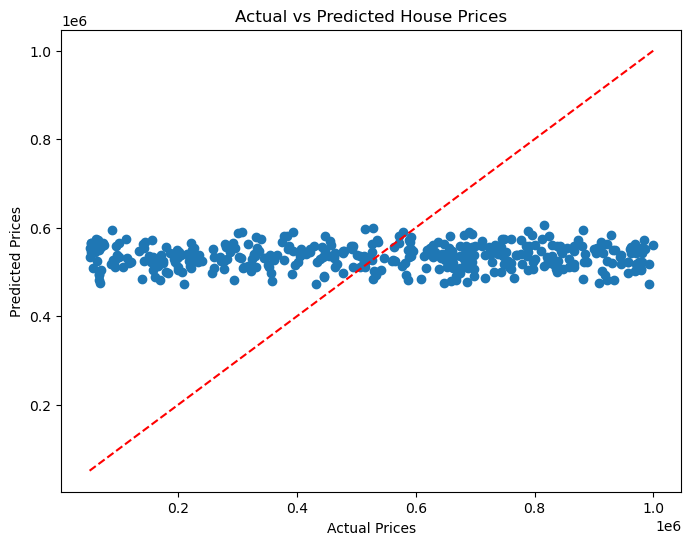

In [23]:
# Actual vs Predicted Visualization

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [24]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nFeature Importance:")
print(importance)


Feature Importance:
              Feature   Coefficient
4              Floors  19030.926950
9      Condition_Fair  10605.827753
7   Location_Suburban   4688.807893
5           YearBuilt   4192.578243
11     Condition_Poor   1916.410443
12         Garage_Yes   1107.866928
6      Location_Rural    782.814737
2            Bedrooms     75.999922
1                Area   -629.807550
8      Location_Urban  -5433.722080
10     Condition_Good  -5485.855833
0                  Id  -6892.134735
3           Bathrooms -10906.548221
